In [1]:
import nextnanopy as nn
import os
import matplotlib.pyplot as plt
import numpy as np
import sys


In [2]:
path_nextnanoprojects_tools = r"C:\Users\sp6497_a\nextnanopy_projects"

In [3]:
print(sys.path)
sys.path.append(path_nextnanoprojects_tools)
print(sys.path)
from nextnano_tools.helper_functions import build_output
from nextnano_tools.simstructs import SimOut, BandStructure, Eigenstate

['c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\python313.zip', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\DLLs', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev', '', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\win32', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\Pythonwin']
['c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\python313.zip', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\DLLs', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev', '', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\win32', 'c:\\Users\\sp6497_a\\min

In [4]:
bias = r'bias_00000'
quantum_region = r'Quantum\quantum_region'
quantum_band = r'kp8'
quantum_band_interactions = r'kp8_kp8'
# quantum_band = r'Gamma'
# quantum_band_interactions = r'Gamma_Gamma'

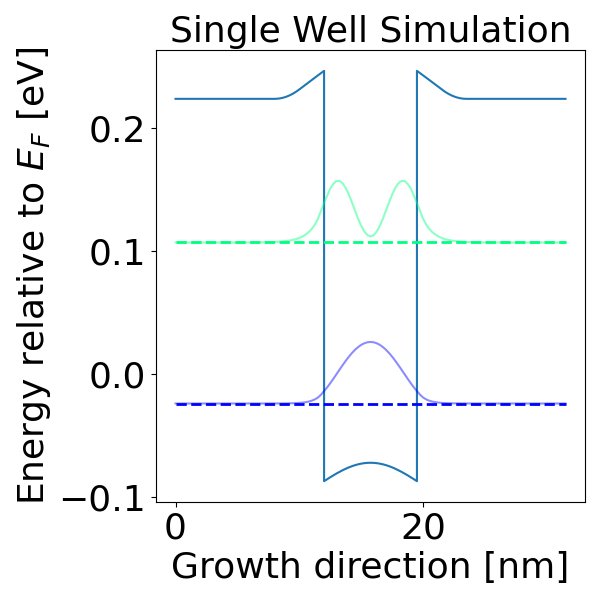


Intersubband transition energies — CB
-----------------------------------------------------
 i → j | ΔE (eV)
-----------------------------------------------------
  1 →  2 | -0.1308
-----------------------------------------------------



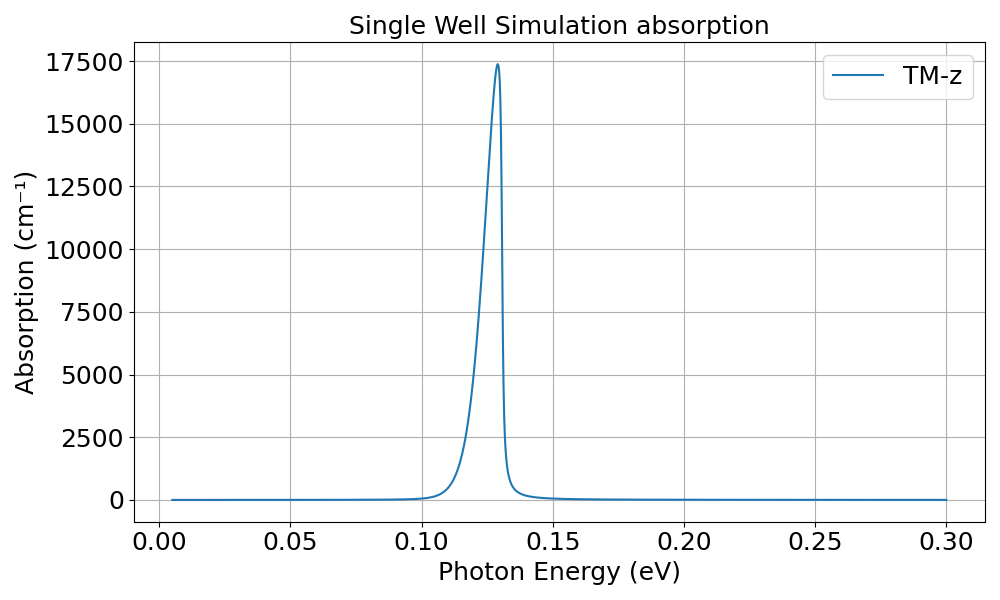

<Axes: title={'center': 'Single Well Simulation absorption'}, xlabel='Photon Energy (eV)', ylabel='Absorption (cm⁻¹)'>

In [6]:
%matplotlib widget
# parent_dir = r'C:\Users\sp6497_a\Documents\nextnano\Output\SW_GaAsAlGaAs_absorption(1)'
# VB_cutoff = -0.5
# simoutidk = build_output(parent_dir,quantum_region,quantum_band,quantum_band_interactions,bias,VB_cutoff,14)
# # simoutidk.plot_all_bands()
# simoutidk.bands['CB'].sort_subbands(decreasing=False)

# simoutidk.plot_all_bands(title_diff='Schrodinger-Poisson 7.5 nm well Al0.4Ga0.6As/GaAs')
# simoutidk.bands['CB'].plot_band(title_diff='Schrodinger-Poisson 7.5 nm well Al0.4Ga0.6As/GaAs',normalize_y=False)

parent_dir = r'C:\Users\sp6497_a\OneDrive - Princeton University\nextnano_outs\Output\SW_GaAs_AlGaAs_alpha_comp(1)'
VB_cutoff = -1.0
simoutidk = build_output(parent_dir,quantum_region,bias,14,quantum_band = quantum_band, quantum_band_interactions = quantum_band_interactions, VB_cutoff=VB_cutoff,model='kp')
simoutidk.bands['CB'].sort_subbands(decreasing=False)

font_base = 26
barrier_len = simoutidk.variables['w_barrier']
well_len = simoutidk.variables['w_well']
temp = simoutidk.variables['temp']

dop_cc = simoutidk.variables['impurity_conc_cc']
Al_x = simoutidk.variables['Al_alloy']
act_E_AlaAs = simoutidk.variables['activation_E_AlAs']

base_title = str(well_len) +' nm well,' + str(barrier_len) + ' nm barrier, T =' + str(temp) + ' K, Nd=' + str(dop_cc) + 'cm^-3, Alx = ' + str(Al_x) + ', $E_{act}=$ ' + str(act_E_AlaAs) + ' eV'
# simout.bands['CB'].
poster_title = 'Single Well Simulation'
fig_band,ax_band = plt.subplots(figsize=(6,6))
simoutidk.bands['CB'].plot_band(ax=ax_band,title_diff=poster_title,normalize_y=False,fontsizetitle=font_base,show_legend=False,fontsizebase=font_base)
simoutidk.bands['CB'].calc_intersubband_transitions()
simoutidk.bands['CB'].display_intersubband_transitions(upward_only=True,sort_by_deltaE="descending")
simoutidk.optical_absorption.get_spectrum('TM-z').plot(show_grid=True,diff_title=poster_title + ' absorption',fontsizetitle=18)